<a href="https://colab.research.google.com/github/pricodingg/ecommerce-forecast-review/blob/main/Ecommerceforecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')

df['Order Date'] = pd.to_datetime(df['Order Date'])

df = df.sort_values('Order Date')
df.set_index('Order Date', inplace=True)

df.head()

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Order Date,,,,,,,,,,,,,,,,,,,,
2014-01-03,7981,CA-2014-103800,1/7/2014,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
2014-01-04,740,CA-2014-112326,1/8/2014,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
2014-01-04,741,CA-2014-112326,1/8/2014,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
2014-01-04,742,CA-2014-112326,1/8/2014,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2014-01-05,1760,CA-2014-141817,1/12/2014,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


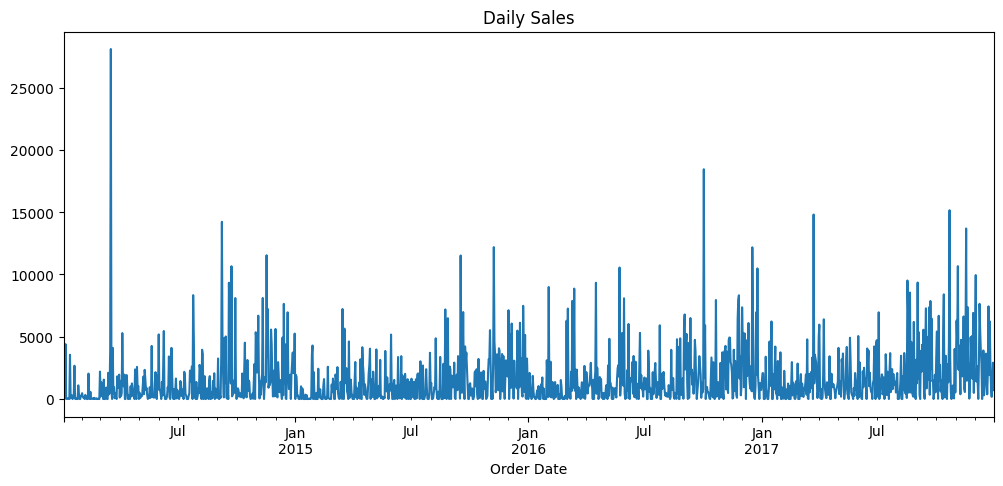

In [3]:
daily_sales = df['Sales'].resample('D').sum()

daily_sales.plot(figsize=(12,5), title="Daily Sales")
plt.show()

In [4]:
result = adfuller(daily_sales)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.939878803531315
p-value: 2.914879072767366e-05


In [6]:
diff_sales = daily_sales.diff().dropna()

# Check again
result = adfuller(diff_sales)
print("p-value after differencing:", result[1])

p-value after differencing: 1.1117457108697706e-26


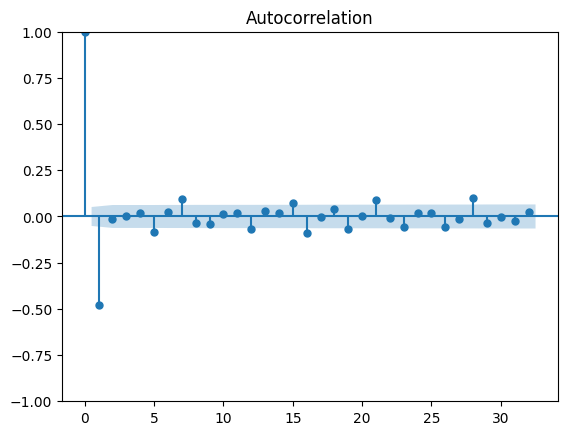

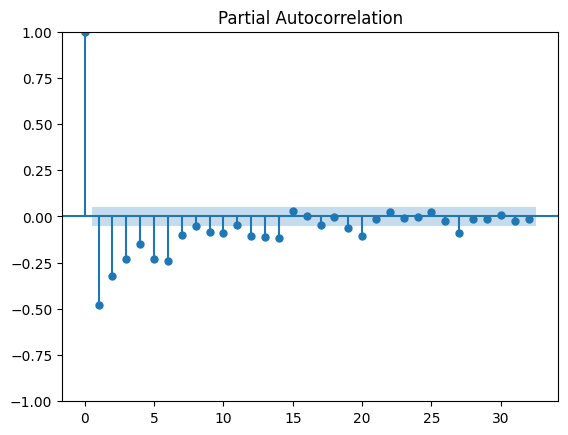

In [7]:
plot_acf(diff_sales)
plot_pacf(diff_sales)
plt.show()

In [8]:
train = daily_sales[:-30]
test = daily_sales[-30:]

In [9]:
model = ARIMA(train, order=(2,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                 1428
Model:                 ARIMA(2, 1, 1)   Log Likelihood              -12979.494
Date:                Fri, 01 May 2026   AIC                          25966.988
Time:                        09:45:41   BIC                          25988.041
Sample:                    01-03-2014   HQIC                         25974.851
                         - 11-30-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0377      0.026      1.432      0.152      -0.014       0.089
ar.L2          0.0042      0.026      0.159      0.874      -0.047       0.056
ma.L1         -0.9610      0.009   -111.104      0.0

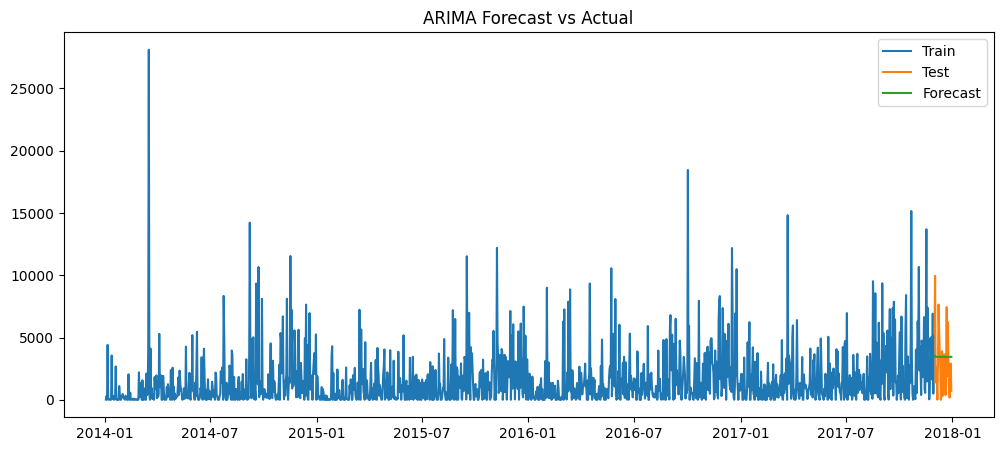

In [10]:
pred = model_fit.forecast(steps=30)

# Plot
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, pred, label='Forecast')
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

In [11]:
mae = mean_absolute_error(test, pred)
rmse = np.sqrt(((test - pred) ** 2).mean())

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2147.069223955443
RMSE: 2556.6619934952114


In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train, order=(2,1,1), seasonal_order=(1,1,1,7))
model_fit = model.fit()

pred = model_fit.forecast(steps=30)